# Latent Probing for Mental Health Sentiment Classification (Gemma)
### Multi-layer probing pipeline

This notebook implements the pipeline described in our Problem Statement and Data Card:
1. Load and clean the dataset
2. Split into train / validation / test
3. Extract latent representations from **Gemma**, across multiple internal layers (not just one)
4. Train a linear probe **per layer** on those latents
5. Compare layers to find which best decodes mental health sentiment (the core "latent probing" question)
6. Check for overfitting at the best layer
7. Evaluate the best-layer probe on the held-out test set

**Before running (important, one-time setup):**
1. Create a free Hugging Face account at https://huggingface.co if you don't have one.
2. Go to https://huggingface.co/google/gemma-2b and click "Agree and access repository" (Gemma is a gated model — you must accept Google's license before you can download it).
3. Create an access token at https://huggingface.co/settings/tokens (a "Read" token is enough).
4. In Colab: Runtime → Change runtime type → set Hardware accelerator to **T4 GPU** (free tier). Embedding extraction over ~38k rows on CPU alone will be very slow.
5. Upload `Combined Data.csv` (left sidebar → Files → upload), or mount Google Drive.


In [1]:
# Step 0: Install required libraries
!pip install -q transformers accelerate huggingface_hub scikit-learn pandas torch matplotlib joblib


In [2]:
# Step 0b: Imports
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import joblib

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cpu":
    print("WARNING: no GPU detected. Go to Runtime > Change runtime type > T4 GPU, then re-run this cell.")


Using device: cuda


In [3]:
# Step 0c: Log in to Hugging Face (required because Gemma is a gated model)
# This will prompt for the access token you created in the setup steps above.
from huggingface_hub import login
login()


In [4]:
from huggingface_hub import login
from getpass import getpass

token = getpass("Paste your Hugging Face token here: ")
login(token=token)


Paste your Hugging Face token here: ··········


In [5]:
# Step 0d: Config
MODEL_NAME = "google/gemma-2b"   # base (non-instruct) model — best for embedding extraction
MAX_LENGTH = 128                 # tokens per input; most posts are short, this covers the bulk of them
BATCH_SIZE = 8                   # lower this if you hit an out-of-memory error on Colab's free GPU

# For a first end-to-end test run, use a fraction of the data so extraction finishes in minutes, not hours.
# Once the pipeline works end-to-end, set this to 1.0 and re-run for your real submission.
SAMPLE_FRAC = 0.5
RANDOM_STATE = 42


## Step 1: Load and clean the dataset

Filters to our four target classes (Depression, Anxiety, Stress, Normal), matching the Data Card.


In [6]:
import zipfile

with zipfile.ZipFile("Combined Data.csv(1).zip", "r") as zip_ref:
    zip_ref.extractall()

import os
print(os.listdir())

['.config', 'Combined Data.csv', 'Combined Data.csv(1).zip', 'sample_data']


In [7]:
# Step 1: Load the CSV
df = pd.read_csv("Combined Data.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (53043, 3)


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [8]:
# Step 1b: Filter to target classes and clean text
TARGET_CLASSES = ["Depression", "Anxiety", "Stress", "Normal"]
df = df[df["status"].isin(TARGET_CLASSES)].copy()

df = df.dropna(subset=["statement"])
df = df[df["statement"].str.strip() != ""]

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"\s+", " ", text).strip()       # collapse whitespace
    return text

df["statement"] = df["statement"].apply(clean_text)
df = df.reset_index(drop=True)

print("Cleaned shape:", df.shape)
print(df["status"].value_counts())


Cleaned shape: (38175, 3)
status
Normal        16343
Depression    15404
Anxiety        3841
Stress         2587
Name: count, dtype: int64


In [9]:
# Step 1c: Optional downsample for faster iteration (stratified, so class balance is preserved)
if SAMPLE_FRAC < 1.0:
    df, _ = train_test_split(
        df, train_size=SAMPLE_FRAC, stratify=df["status"], random_state=RANDOM_STATE
    )
    df = df.reset_index(drop=True)

print("Working shape:", df.shape)
print(df["status"].value_counts())


Working shape: (19087, 3)
status
Normal        8171
Depression    7702
Anxiety       1920
Stress        1294
Name: count, dtype: int64


## Step 2: Split into train / validation / test

Stratified on the label. The test set is only touched once, at the very end.


In [10]:
# Step 2: Encode labels and split
le = LabelEncoder()
df["label"] = le.fit_transform(df["status"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RANDOM_STATE
)

print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)


{'Anxiety': np.int64(0), 'Depression': np.int64(1), 'Normal': np.int64(2), 'Stress': np.int64(3)}
Train: (13360, 4)  Val: (2863, 4)  Test: (2864, 4)


## Step 3: Load Gemma and extract latent representations from every layer

Unlike DistilBERT, Gemma is decoder-only and has no `[CLS]` token, so we mean-pool each
layer's hidden states over the (non-padding) tokens to get one fixed-size vector per layer,
per example. We keep every layer's output so we can probe each one separately in Step 4 —
this is the "record and extract internal embeddings across different layers" step from the
problem statement.


In [11]:
# Step 3a: Load tokenizer and model (frozen — we are NOT fine-tuning Gemma)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Gemma has no pad token by default

model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)
model.eval()

N_LAYERS = model.config.num_hidden_layers + 1  # +1 because hidden_states includes the embedding layer output
print(f"Model loaded. Hidden size: {model.config.hidden_size}, layers (incl. embedding layer): {N_LAYERS}")


config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/33.6k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

Model loaded. Hidden size: 2048, layers (incl. embedding layer): 19


In [12]:
# Step 3b: Function to extract mean-pooled hidden states from every layer, for a batch of texts
@torch.no_grad()
def get_all_layer_embeddings(texts, batch_size=BATCH_SIZE, max_length=MAX_LENGTH):
    """
    Returns an array of shape (n_texts, N_LAYERS, hidden_size).
    For each layer, we mean-pool over the real (non-padding) tokens.
    """
    all_layer_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt"
        ).to(device)

        output = model(**encoded)
        hidden_states = output.hidden_states  # tuple of (batch, seq_len, hidden) — one per layer

        attention_mask = encoded["attention_mask"].unsqueeze(-1)  # (batch, seq_len, 1)
        lengths = attention_mask.sum(dim=1).clamp(min=1)          # (batch, 1)

        layer_vecs_for_batch = []
        for layer_hidden in hidden_states:
            masked = layer_hidden * attention_mask          # zero out padding positions
            pooled = masked.sum(dim=1) / lengths             # mean over real tokens
            layer_vecs_for_batch.append(pooled.float().cpu().numpy())

        # shape: (n_layers, batch, hidden) -> (batch, n_layers, hidden)
        batch_array = np.stack(layer_vecs_for_batch, axis=1)
        all_layer_vecs.append(batch_array)

        if (i // batch_size) % 20 == 0:
            print(f"  processed {i + len(batch)}/{len(texts)}")

    return np.concatenate(all_layer_vecs, axis=0)


In [13]:
# Step 3c: Run extraction on each split (this is the slow step — grab a coffee)
print("Extracting train embeddings...")
X_train_all_layers = get_all_layer_embeddings(train_df["statement"].tolist())
print("Extracting validation embeddings...")
X_val_all_layers = get_all_layer_embeddings(val_df["statement"].tolist())
print("Extracting test embeddings...")
X_test_all_layers = get_all_layer_embeddings(test_df["statement"].tolist())

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print(X_train_all_layers.shape, X_val_all_layers.shape, X_test_all_layers.shape)

# Optional: cache to disk so you don't have to re-run extraction if your Colab session drops
np.save("X_train_all_layers.npy", X_train_all_layers)
np.save("X_val_all_layers.npy", X_val_all_layers)
np.save("X_test_all_layers.npy", X_test_all_layers)
np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)


Extracting train embeddings...
  processed 8/13360
  processed 168/13360
  processed 328/13360
  processed 488/13360
  processed 648/13360
  processed 808/13360
  processed 968/13360
  processed 1128/13360
  processed 1288/13360
  processed 1448/13360
  processed 1608/13360
  processed 1768/13360
  processed 1928/13360
  processed 2088/13360
  processed 2248/13360
  processed 2408/13360
  processed 2568/13360
  processed 2728/13360
  processed 2888/13360
  processed 3048/13360
  processed 3208/13360
  processed 3368/13360
  processed 3528/13360
  processed 3688/13360
  processed 3848/13360
  processed 4008/13360
  processed 4168/13360
  processed 4328/13360
  processed 4488/13360
  processed 4648/13360
  processed 4808/13360
  processed 4968/13360
  processed 5128/13360
  processed 5288/13360
  processed 5448/13360
  processed 5608/13360
  processed 5768/13360
  processed 5928/13360
  processed 6088/13360
  processed 6248/13360
  processed 6408/13360
  processed 6568/13360
  processed 

## Step 4: Train a linear probe per layer

This is the actual "latent probing" experiment: we train a separate simple linear classifier
on each layer's embeddings, then compare validation accuracy across layers to see which part
of Gemma's internal representation best encodes mental health sentiment.


In [15]:
# Step 4: Train and evaluate a probe for every layer
layer_results = []

for layer_idx in range(N_LAYERS):
    X_tr = X_train_all_layers[:, layer_idx, :]
    X_v = X_val_all_layers[:, layer_idx, :]

    probe = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        C=1.0,
        random_state=RANDOM_STATE,
    )
    probe.fit(X_tr, y_train)

    train_acc = accuracy_score(y_train, probe.predict(X_tr))
    val_acc = accuracy_score(y_val, probe.predict(X_v))

    layer_results.append({
        "layer": layer_idx,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "gap": train_acc - val_acc,
    })
    print(f"Layer {layer_idx:2d} | train acc: {train_acc:.3f} | val acc: {val_acc:.3f} | gap: {train_acc - val_acc:.3f}")

results_df = pd.DataFrame(layer_results)
results_df


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Layer  0 | train acc: 0.985 | val acc: 0.872 | gap: 0.113


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Layer  1 | train acc: 0.992 | val acc: 0.885 | gap: 0.107


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Layer 17 | train acc: 1.000 | val acc: 0.887 | gap: 0.113


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Layer 18 | train acc: 0.992 | val acc: 0.890 | gap: 0.102


,layer,train_acc,val_acc,gap
0,0,0.984581,0.871813,0.112768
1,1,0.992290,0.885435,0.106856
2,2,0.987725,0.889976,0.097749
3,3,0.988772,0.893119,0.095653
4,4,0.990943,0.889976,0.100968
5,5,0.989895,0.895564,0.094331
6,6,0.990644,0.898708,0.091936
7,7,0.994760,0.899756,0.095005
8,8,0.993713,0.901502,0.092211
9,9,0.994012,0.896612,0.097400


## Step 5: Compare layers

Plot validation accuracy by layer. This chart itself is a useful artifact for your README —
it directly answers "how effectively can shallow classifiers decode mental health sentiment
from internal states" at each depth of the model.


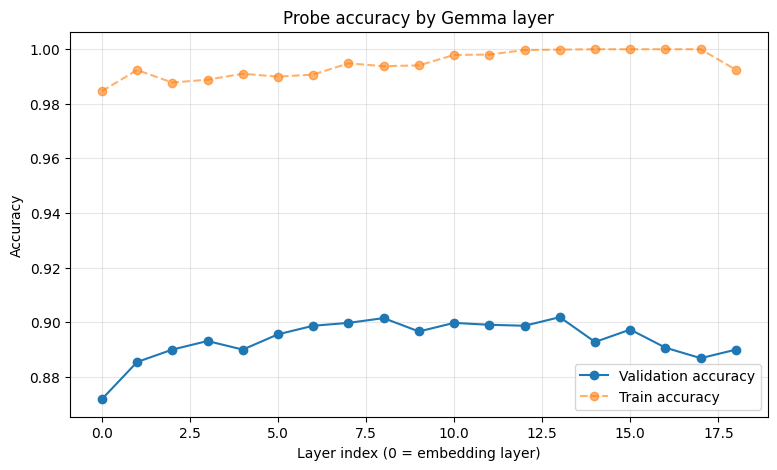

Best layer: 13 (val acc: 0.902, gap: 0.098)


In [17]:
# Step 5: Plot layer vs. validation accuracy
plt.figure(figsize=(9, 5))
plt.plot(results_df["layer"], results_df["val_acc"], marker="o", label="Validation accuracy")
plt.plot(results_df["layer"], results_df["train_acc"], marker="o", linestyle="--", alpha=0.6, label="Train accuracy")
plt.xlabel("Layer index (0 = embedding layer)")
plt.ylabel("Accuracy")
plt.title("Probe accuracy by Gemma layer")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("layer_accuracy_plot.png", dpi=150, bbox_inches="tight")
plt.show()

best_row = results_df.loc[results_df["val_acc"].idxmax()]
BEST_LAYER = int(best_row["layer"])
print(f"Best layer: {BEST_LAYER} (val acc: {best_row['val_acc']:.3f}, gap: {best_row['gap']:.3f})")


## Step 6: Check for overfitting at the best layer

If train accuracy is much higher than validation accuracy (gap > ~0.15), the probe is
memorizing rather than generalizing.

**If you see overfitting, try:**
- Lowering `C` in the LogisticRegression (more regularization)
- Picking a layer with a smaller train/val gap even if its raw accuracy is slightly lower
- Increasing training data (raise `SAMPLE_FRAC`)


In [18]:
# Step 6: Overfitting check at the best layer
gap = best_row["gap"]
print(f"Train/Validation accuracy gap at layer {BEST_LAYER}: {gap:.3f}")
if gap > 0.15:
    print("Warning: possible overfitting — consider stronger regularization (lower C) or more data.")
else:
    print("Gap looks reasonable.")


Train/Validation accuracy gap at layer 13: 0.098
Gap looks reasonable.


## Step 7: Final evaluation on the held-out test set

Only run this once you're satisfied with validation performance. This is your honest,
final measure of how well the model generalizes to unseen data — matches the "Evaluation"
section required in your README.


In [19]:
# Step 7: Refit the best-layer probe and evaluate on test
X_tr_best = X_train_all_layers[:, BEST_LAYER, :]
X_test_best = X_test_all_layers[:, BEST_LAYER, :]

final_probe = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=1.0,
    random_state=RANDOM_STATE,
)
final_probe.fit(X_tr_best, y_train)

y_pred = final_probe.predict(X_test_best)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))


Test accuracy: 0.9053770949720671

              precision    recall  f1-score   support

     Anxiety       0.77      0.83      0.80       288
  Depression       0.93      0.94      0.94      1156
      Normal       0.96      0.93      0.94      1226
      Stress       0.64      0.69      0.66       194

    accuracy                           0.91      2864
   macro avg       0.83      0.85      0.83      2864
weighted avg       0.91      0.91      0.91      2864



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 8: Predict with probability distributions on new text

This is the "latent probe signal" your Data Card describes: not just a label, but a full
probability distribution across all four classes, from the best-performing layer.


In [20]:
# Step 8: Try it on new text
def predict_with_probabilities(text):
    all_layers = get_all_layer_embeddings([text])
    embedding = all_layers[:, BEST_LAYER, :]
    probs = final_probe.predict_proba(embedding)[0]
    result = {label: round(float(prob) * 100, 1) for label, prob in zip(le.classes_, probs)}
    return dict(sorted(result.items(), key=lambda x: -x[1]))

sample_text = "I can't sleep, everything feels pointless lately, nothing excites me anymore"
print(predict_with_probabilities(sample_text))


  processed 1/1
{'Anxiety': 98.3, 'Stress': 1.5, 'Depression': 0.2, 'Normal': 0.0}


In [21]:
# Step 9: Save the final probe and metadata so you don't have to retrain from scratch
joblib.dump(final_probe, "probe_model.pkl")
joblib.dump(le, "label_encoder.pkl")
with open("best_layer.txt", "w") as f:
    f.write(str(BEST_LAYER))

print(f"Saved probe_model.pkl, label_encoder.pkl, and best_layer.txt (best layer = {BEST_LAYER})")


Saved probe_model.pkl, label_encoder.pkl, and best_layer.txt (best layer = 13)


## Next steps

- Once this runs end-to-end with `SAMPLE_FRAC = 0.15`, set `SAMPLE_FRAC = 1.0` and re-run for your real submission numbers.
- Cross-check a sample of predictions against your DSM-5-based labeling rubric from the Data Card (the 50–100 post relabeling check).
- Document which classes the model struggles with most — likely Stress vs Normal, given they're semantically closer and Stress has the fewest examples.
- The `layer_accuracy_plot.png` saved in Step 5 is a good figure to include directly in your README's Evaluation section.
- If Colab's free GPU runs out of memory, lower `BATCH_SIZE` in the config cell (try 4), or lower `MAX_LENGTH`.
